# Possession & Ball Control

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# import data
df = pd.read_csv("players_data-2024_2025.csv")

Matplotlib is building the font cache; this may take a moment.


In [31]:
Comp = df['Comp'].value_counts().head(5).index
df_top5_comp = df[df['Comp'].isin(Comp)]
df_top5_comp

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,2000.0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,2004.0,6,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,2006.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2849,2850,Edhy Zuliani,fr FRA,DF,Toulouse,fr Ligue 1,19.0,2004.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2850,2851,Szymon Żurkowski,pl POL,MF,Empoli,it Serie A,26.0,1997.0,5,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2851,2852,Martin Ødegaard,no NOR,MF,Arsenal,eng Premier League,25.0,1998.0,30,26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2852,2853,Milan Đurić,ba BIH,FW,Monza,it Serie A,34.0,1990.0,18,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Touches

Text(0.5, 1.0, 'Top 5 Goal Scorers by Efficiency (Touch per Goals)')

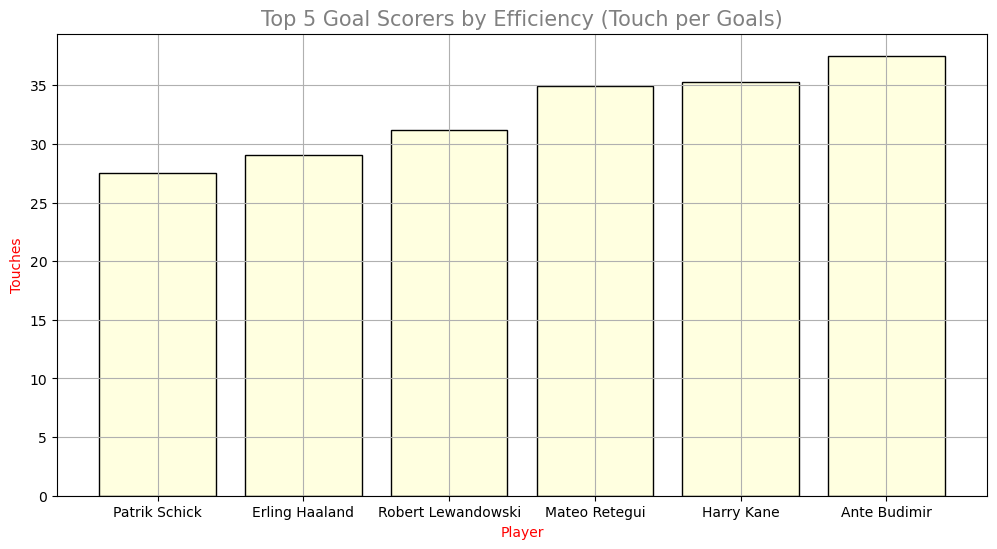

In [66]:
df_top5_comp_filtered = df_top5_comp[df_top5_comp['Gls'] > 20].copy()

df_top5_comp_filtered['Touches_per_goal'] = df_top5_comp_filtered['Touches'] / df_top5_comp_filtered['Gls']

top_scorers = df_top5_comp_filtered[['Player', 'Gls', 'Touches', 'Touches_per_goal']].sort_values(by='Touches_per_goal').head(6)


plt.figure(figsize=(12,6))
plt.bar(top_scorers['Player'], top_scorers['Touches_per_goal'], color='lightyellow', edgecolor='black')
plt.grid()
plt.xlabel('Player', size=10, color='red')
plt.ylabel('Touches', size=10, color='red')
plt.title('Top 5 Goal Scorers by Efficiency (Touch per Goals)', color='grey', size=15)


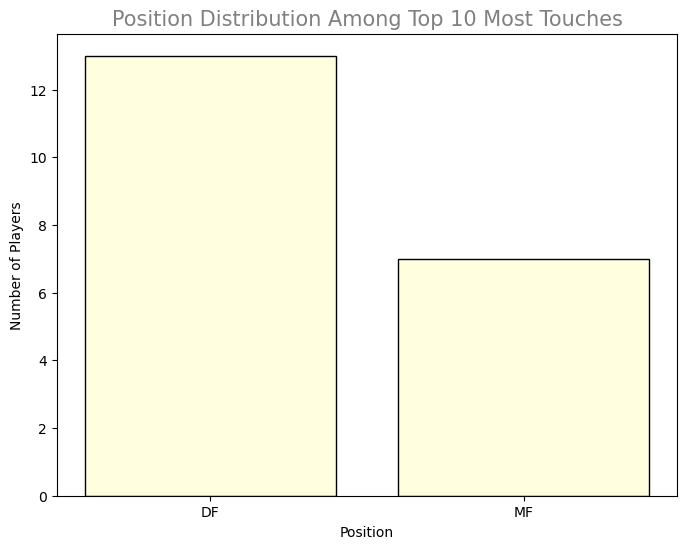

In [88]:
top_touches = df_top5_comp[['Player', 'Pos', 'Touches']].sort_values(by='Touches', ascending=False).head(20)

pos_counts = top_touches['Pos'].value_counts()

plt.figure(figsize=(8,6))
plt.bar(pos_counts.index, pos_counts.values, edgecolor='black', color='lightyellow')
plt.title('Position Distribution Among Top 10 Most Touches', color='grey', size=15)
plt.xlabel('Position', size=10)
plt.ylabel('Number of Players', size=10)
plt.show()


## Players who lose the ball the most

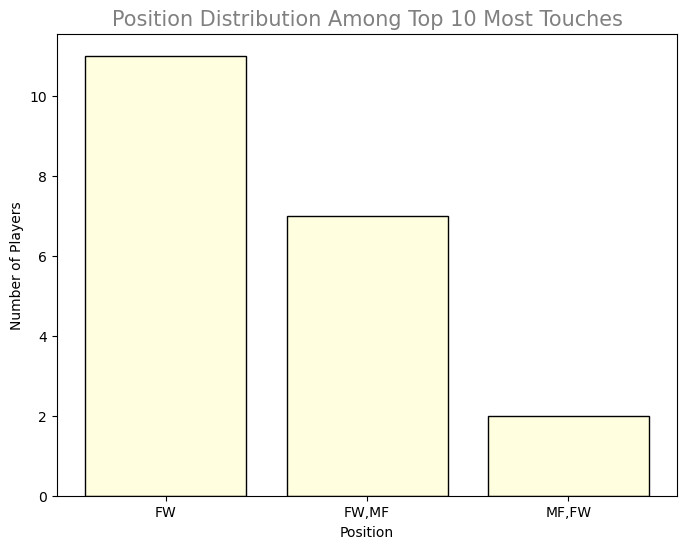

In [96]:
df_top5_comp['ball_loss'] = df_top5_comp['Mis'] + df_top5_comp['Dis']
ball_loss = df_top5_comp[['Player', 'Pos', 'ball_loss']].sort_values(by='ball_loss', ascending=False).head(20)
loss_count = ball_loss['Pos'].value_counts()
plt.figure(figsize=(8,6))
plt.bar(loss_count.index, loss_count.values, edgecolor='black', color='lightyellow')
plt.title('Position Distribution Among Top 10 Most Touches', color='grey', size=15)
plt.xlabel('Position', size=10)
plt.ylabel('Number of Players', size=10)
plt.show()